# Band Structure of Surface Plasmon Polaritons 
In this note,  I will show how to capture the SPP dispersions using the excitation method.
The steps of the method are
1. Excite SPP using a Gaussian source near the metal.
2. Record the electric field after the source as a function of $t$.
3. Use `harminv` to analyze the field as a function of $t$.

Since the SPPs are confined modes near the surface with small quality factors $0<Q<150$, the method is tricky. The following points should be carefully taken:
 - The source should be a E field normal to the surface. The position of the source should be close to the surface
 - Recording field should begin after the source. But "after the source" is not clearly defined. Some try and error should be made.
 - Metal is a dispersive material. In FDTD (meep), it requires `resolution` to be large otherwise the simulation might lead to NaN (not a number). Typically, `resolution` > 50
 - Use `mp.Absorber` for the boundary layer
 - Use `harminv` in the terminal and do some proper setting as below. 

In [17]:
import meep as mp
import numpy as np
from matplotlib import pyplot as plt
from meep.materials import Al, Ag, SiO2
from IPython.display import Video

In [18]:
# Some parameters to describe the geometry:
resolution = 250
w = 1 # thickness of the metal film
# The cell dimensions
sy = 3  # size of cell in y direction 
sx = 0.1 # periodical in x
dpml = 0.5  # PML thickness (y direction only!)
cell = mp.Vector3(sx, sy)
# 
sr_y = w/2 + 0.01 # the source is  just above the surface

b = mp.Block(size=mp.Vector3(sx, w, ), material=Ag) # metal film
geometry = [b]

# boundary layer
boundary_layers=[mp.Absorber(thickness=dpml, direction=mp.Y)] ## !! Here, I do not use pml since pml can not deal with wave propagating parallel to the plane

# source 

fcen = 1.25  # pulse center frequency
df = 2  # pulse freq. width: large df = short impulse
s = [
    mp.Source(
        src=mp.GaussianSource(fcen, fwidth=df),
        component=mp.Ey,
        size=mp.Vector3(sx,0,0),
        center=mp.Vector3(0, sr_y),
    )
]

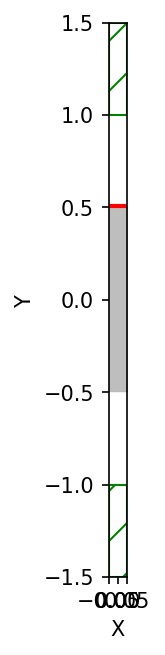

In [19]:
# plot the structure
sim = mp.Simulation(
    cell_size=cell,
    geometry=geometry,
    boundary_layers=boundary_layers,
    sources=s,
    resolution=resolution,
)
f = plt.figure(dpi=150)
## epsilson_metal is negative. eps_parameters should be properly set as follows. 
sim.plot2D(ax=f.gca(),eps_parameters={'cmap':'gray','vmin':-50.5,'alpha':0.5}) 
plt.show()

Below, I collect the $E_y$ field at the excitation point and use it for `harminv`.
The k point is $k_x= 0.5$ in unit of $2\pi/s_x$, where $s_x$ is the length of the cell in the $x$ direction. The data is saved in `"ey_time_data.txt"`.

FloatProgress(value=0.0, description='0% done ', max=30.0)

FloatProgress(value=0.0, description='0% done ', max=30.0)

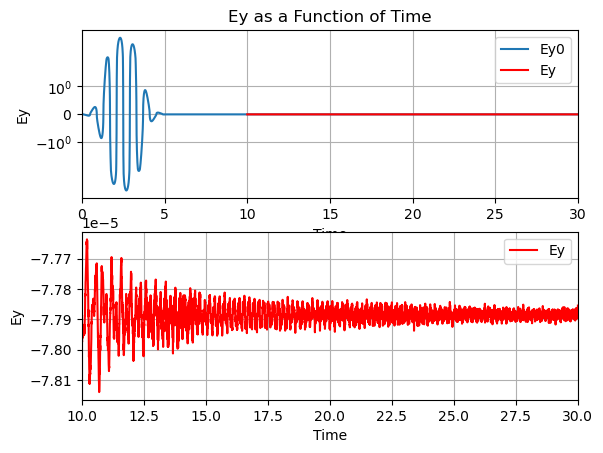

Ey and time data saved to: ey_time_data.txt


In [20]:
# List to store Ey and time values
ey0_data =[] # no structure
time0_data = [] # no structure
ey_data = []
time_data = []

# Function to collect Ey at a specific point
def collect_ey0(sim):
    ey0 = sim.get_field_point(mp.Ey, mp.Vector3(0, sr_y))
    ey0_data.append(ey0)
    time0_data.append(sim.meep_time())
    
def collect_ey(sim):
    ey = sim.get_field_point(mp.Ey, mp.Vector3(0, sr_y))
    ey_data.append(ey)
    time_data.append(sim.meep_time())

kx = 0.5 / sx

## no structure run
sim.reset_meep()  # Reset the simulation
#sim.restart_fields()
sim = mp.Simulation(
    cell_size=cell,
    boundary_layers=boundary_layers,
    sources=s,
    resolution=resolution,
    k_point = mp.Vector3(kx)
)

# Run simulation, collecting Ey at every time step
sim.run(
    mp.after_time(0,mp.at_every(1/resolution, collect_ey0)),  # Collect Ey every 0.1 time units
    until=30
)

# Convert data to numpy arrays for plotting
ey0_data = np.array(ey0_data)
time0_data = np.array(time0_data)



## real run

sim.reset_meep()  # Reset the simulation
#sim.restart_fields()
sim = mp.Simulation(
    cell_size=cell,
    geometry=geometry,
    boundary_layers=boundary_layers,
    sources=s,
    resolution=resolution,
    k_point = mp.Vector3(kx) 
)



# Run simulation, collecting Ey at every time step
sim.run(
    mp.after_time(10,mp.at_every(1/resolution, collect_ey)),  # Collect Ey every 0.1 time units
    until=30
)

# Convert data to numpy arrays for plotting
ey_data = np.array(ey_data)
time_data = np.array(time_data)

# Plot Ey vs. time
ey0_re = np.real(ey0_data)
y0 = np.sign(ey0_re) * np.abs(ey0_re)**0.5  
ey_re = np.real(ey_data)
y = np.sign(ey_re) * np.abs(ey_re)**0.5  
plt.subplot(2,1,1)
plt.plot(time0_data, y0,'-' ,label='Ey0')
plt.plot(time_data, y, 'r',label='Ey')
plt.xlabel('Time')
plt.ylabel('Ey')
plt.title('Ey as a Function of Time')
plt.yscale('symlog')
plt.legend()
plt.xlim([0,30])
plt.grid(True)
plt.subplot(2,1,2)
plt.plot(time_data, ey_re,'r', label='Ey')
plt.xlabel('Time')
plt.ylabel('Ey')
plt.legend()
plt.xlim([10,30])
plt.grid(True)
plt.show()

# Save the time and Ey data to a file
filename = "ey_time_data.txt"
with open(filename, "w") as f:
    for t, ey in zip(time_data, ey_data):
        f.write(f"{ey.real}+{ey.imag}i\n") # Save time, Ey

print(f"Ey and time data saved to: {filename}")


We can use `os` to execute the linux command. Note that `harminv` is pre-compiled with OpenMP support for multi-threading. Without setting, it will use all the available cores. We need to limit it by `OMP_NUM_THREADS=1 `.  

In [21]:
import os
## !! set  -t 1/resolution, since mp.after_time(10,mp.at_every(1/resolution, collect_ey))
cmd_str1 = f"OMP_NUM_THREADS=1 harminv -t {1/resolution} -Q 1 0-3 < ey_time_data.txt" 
os.system(cmd_str1)

frequency, decay constant, Q, amplitude, phase, error
2.8425, 6.571365e-01, 13.5892, 1.63014e-07, 3.01681, 1.765917e-05


0

We can also use `subprocess` to execute the linux command and handle the data in python as below.

In [22]:
import subprocess

# Run harminv command and capture output
## set  -t 1/resolution
cmd = f"OMP_NUM_THREADS=1 harminv -t {1/resolution} -Q 1 0-3 < ey_time_data.txt" 
result = subprocess.run(cmd, shell=True, capture_output=True, text=True)

# Process the output
output = result.stdout.splitlines()
frequencies = []
fre_k = []

# Skip header and extract positive frequencies
for line in output:
    if line.startswith("frequency") or not line.strip():
        continue  # Skip header or empty lines
    try:
        freq = np.float64(line.split(",")[0].strip())
        if freq > 0:
            frequencies.append(freq)
    except (ValueError, IndexError):
        continue  # Skip invalid lines
fre_k.append(frequencies)
print(fre_k)

[[2.8425]]


In [23]:
# Define a function to catch the mode freqeuncies at a given k_x
def sim_k_point_harminv(sim,kx):
    ey_tmp =[] # 
    time_tmp = [] # 
    
    def collect_ey_tmp(sim):
        ey = sim.get_field_point(mp.Ey, mp.Vector3(0, sr_y))
        ey_tmp.append(ey)
        time_tmp.append(sim.meep_time())

    ##
    sim.reset_meep()  # Reset the simulation
   #sim.restart_fields()
    sim = mp.Simulation(
        cell_size=cell,
        geometry=geometry,
        boundary_layers=boundary_layers,
        sources=s,
        resolution=resolution,
        k_point = mp.Vector3(kx) 
        )
    # Run simulation, collecting Ey at every time step
    sim.run(
        mp.after_time(10,mp.at_every(1/resolution, collect_ey_tmp)),  # Collect Ey every 0.1 time units
        until=30
    )

    # Convert data to numpy arrays for plotting
    ey_tmp = np.array(ey_tmp)
    time_tmp= np.array(time_tmp)

    # 
    # Save the time and Ey data to a file
    filename = "ey_time_tmp.txt"
    with open(filename, "w") as f:
        for t, ey in zip(time_tmp, ey_tmp):
            f.write(f"{ey.real}+{ey.imag}i\n") # Save time, Ey
    
    # Run harminv command and capture output
    cmd = f"OMP_NUM_THREADS=1 harminv -t {1/resolution} -Q 1 0-3 < {filename}" 
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)

    # Process the output
    output = result.stdout.splitlines()
    frequencies = []

    # Skip header and extract positive frequencies
    for line in output:
        if line.startswith("frequency") or not line.strip():
            continue  # Skip header or empty lines
        try:
            freq = np.float64(line.split(",")[0].strip())
            if freq > 0:
                frequencies.append(freq)
        except (ValueError, IndexError):
            continue  # Skip invalid lines
    return frequencies
    

In [24]:
##test the function
fre = sim_k_point_harminv(sim,0.5/sx)
print(fre)

FloatProgress(value=0.0, description='0% done ', max=30.0)

[2.8425]


In [25]:
nk = 101
kpoint = np.linspace(0,0.5,nk) / sx
fre_kx = []

for i in range(nk):
    mp.verbosity(0) # Reset verbosity to minimal
    fre_tmp = sim_k_point_harminv(sim,kpoint[i])
    fre_kx.append(fre_tmp)
    print(f'{i}/{nk} \n')

FloatProgress(value=0.0, description='0% done ', max=30.0)

0/101 



FloatProgress(value=0.0, description='0% done ', max=30.0)

1/101 



FloatProgress(value=0.0, description='0% done ', max=30.0)

...

98/101 



FloatProgress(value=0.0, description='0% done ', max=30.0)

99/101 



FloatProgress(value=0.0, description='0% done ', max=30.0)

100/101 



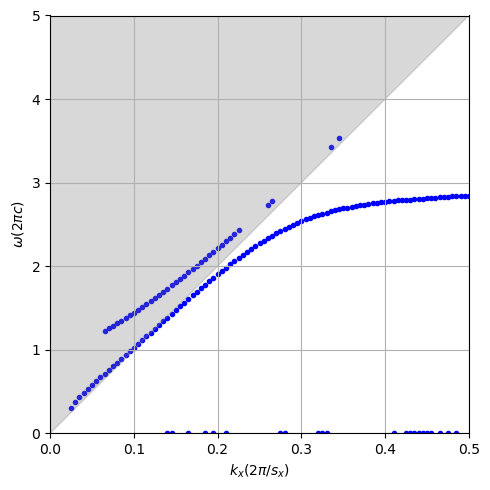

In [26]:
fig = plt.figure(dpi=100, figsize=(5, 5))
ax = plt.subplot(111)
for i in range(nk):
    for ii in range(len(fre_kx[i])):
        plt.scatter(kpoint[i]*sx, fre_kx[i][ii], color="b",marker='.')

ax.fill_between(kpoint,  kpoint/sx, 5.0, interpolate=True, color="gray", alpha=0.3)
plt.xlim(0, 0.5)
plt.ylim(0, 5)
plt.grid(True)
plt.xlabel("$k_x(2\pi/s_x)$")
plt.ylabel("$\omega(2\pi c)$")
plt.tight_layout()
plt.show()

The SPP dispesions on a semi-infinite metal surface can be obtained by
$$ k_1^z\epsilon_0 + k_0^z\epsilon_1 = 0,$$
where$\epsilon_0=1$ and $\epsilon_1 = \epsilon_{\mathrm{metal}}$ 
and 
\begin{align}k_1^z = \sqrt{\epsilon_1 k_0^2 - q^2}\end{align}
$$k_0^z = \sqrt{\epsilon_0 k_0^2 - q^2}$$
and 
$k_0=\frac{\omega}{c}$

$$\frac{q^2 - \epsilon_1 k_0^2}{q^2 - \epsilon_0 k_0^2} = \frac{\epsilon_1^2}{\epsilon_0^2}$$

$$(\epsilon_0^2-\epsilon_1^2)q^2 = (\epsilon_0^2\epsilon_1 - \epsilon_0\epsilon_1^2)  k_0^2$$
$$q = \sqrt{\frac{\epsilon_0\epsilon_1}{\epsilon_0+\epsilon_1}} k_0$$


$$\omega = \sqrt{\frac{\epsilon_0+\epsilon_1}{\epsilon_0\epsilon_1}} cq$$

In [27]:
# Frequency array in Meep units (f = c/a)
f_ls = np.linspace(0.1, 4, 100)  # Adjust range if not in Meep units
k_ls = f_ls*sx
# Function to compute epsilon for silver at a given frequency
def epsilon_Ag(f):
    """
    Compute the dielectric function epsilon for silver at frequency f (Meep units).
    Args:
        f (float): Frequency in Meep units (c/a).
    Returns:
        complex: Dielectric function epsilon(f).
    """
    eps_tensor = Ag.epsilon(f)
    return eps_tensor[0][0]  # Scalar epsilon for isotropic material

# Compute epsilon for each frequency in f_ls
epsilon_1 = np.array([epsilon_Ag(f) for f in f_ls])
k_spp = np.real(np.sqrt( epsilon_1/(1+epsilon_1 )))  * f_ls * sx
# omega_spp = np.sqrt( np.real(epsilon_1+1)/np.real(epsilon_1 )) * k_ls/sx

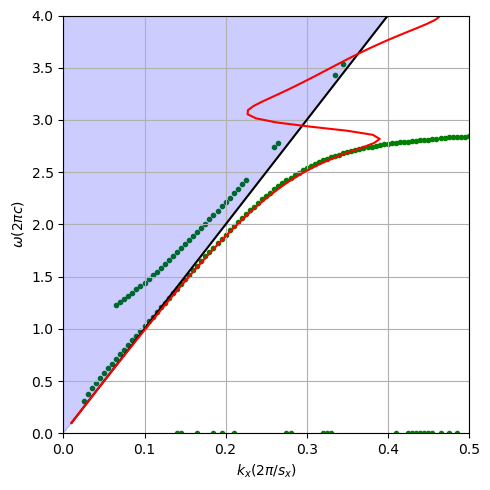

In [28]:
fig = plt.figure(dpi=100, figsize=(5, 5))
ax = plt.subplot(111)
for i in range(nk):
    for ii in range(len(fre_kx[i])):
        plt.scatter(kpoint[i]*sx, fre_kx[i][ii], color="green",marker='.')

ax.fill_between(kpoint,  kpoint/sx, 5.0, interpolate=True, color="blue", alpha=0.2)
plt.plot(k_ls,f_ls,'k')
plt.plot(k_spp,f_ls,'r')
plt.xlim(0, 0.5)
plt.ylim(0, 4)
plt.grid(True)
plt.xlabel("$k_x(2\pi/s_x)$")
plt.ylabel("$\omega(2\pi c)$")
plt.tight_layout()
plt.show()